# Project 02: Visual Word Recognition & Morphological Processing

**Synthetic RT LMM Learning Exercise Inspired by Masked Morphological Priming**

**Disclaimer:** This notebook uses synthetic reaction-time observations and fits a participant random-intercept model only. It does not use human data, implement a masked lexical-decision task, or fit a crossed subject-item model.

## 1. Project Objective

This notebook generates and analyzes synthetic RT observations for three condition labels loosely inspired by masked morphological-priming research. No prime-target strings, masking procedure, lexical-decision responses, or accuracy data are generated or analyzed.

The fitted model predicts RT from `Condition` and includes a random intercept for synthetic participant ID. Item-specific intercepts are included in the data-generating process but omitted from the fitted model. Consequently, the model's standard errors, confidence intervals, and p-values do not account for item-level clustering.

**Synthetic condition labels:** `Morphological`, `Orthographic`, and `Unrelated`. These labels do not reproduce the participants, materials, design, or analyses of the cited studies.

**Interpretive scope:** The data-generating equation prespecifies condition offsets of -40 ms and -10 ms relative to `Unrelated`. The fitted coefficients are compared descriptively with these inputs. Statistical significance is not a criterion for successful recovery and is not empirical evidence of priming in human readers.

## 2. Technical Stack

- **Data manipulation:** `pandas`, `numpy`
- **Statistical modeling:** `statsmodels`
- **Visualization:** `seaborn`, `matplotlib`

## 3. Conceptual References

- Beyersmann, E., Castles, A., & Coltheart, M. (2012). Morphological processing during visual word recognition in developing readers: Evidence from masked priming. *The Quarterly Journal of Experimental Psychology, 65*(7), 1306-1326. https://doi.org/10.1080/17470218.2012.656661
- Beyersmann, E., Ziegler, J. C., Castles, A., Coltheart, M., Kezilas, Y., & Grainger, J. (2016). Morpho-orthographic segmentation without semantics. *Psychonomic Bulletin & Review, 23*(2), 533-539. https://doi.org/10.3758/s13423-015-0927-z

The cited studies provide conceptual background for the condition labels only. All numerical values and variance components below are manually selected for illustration; they are not parameter estimates taken from, or fitted to, either study.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")
plt.rcParams["axes.unicode_minus"] = False

# Synthetic data generation
np.random.seed(42)

n_subjects = 40          # synthetic participant IDs
n_items_per_cond = 30    # synthetic item IDs per condition
conditions = ["Morphological", "Orthographic", "Unrelated"]

base_rt = 650            # manually selected synthetic baseline (ms)
condition_offsets = {
    "Morphological": -40,
    "Orthographic": -10,
    "Unrelated": 0,
}

subject_intercepts = np.random.normal(0, 50, n_subjects)
# These item-specific intercepts are generated but omitted from the fitted model.
item_intercepts = {
    condition: np.random.normal(0, 30, n_items_per_cond)
    for condition in conditions
}

rows = []
for subject in range(n_subjects):
    for condition in conditions:
        for item in range(n_items_per_cond):
            residual_noise = np.random.normal(0, 40)
            rt = (
                base_rt
                + condition_offsets[condition]
                + subject_intercepts[subject]
                + item_intercepts[condition][item]
                + residual_noise
            )
            rows.append(
                {
                    "Subject": f"S{subject + 1:03d}",
                    "Condition": condition,
                    "Item": f"Item_{condition}_{item + 1:02d}",
                    "RT": rt,
                }
            )

df_exp = pd.DataFrame(rows)
print(f"Generated synthetic dataset shape: {df_exp.shape}")
print(df_exp.head())

Generated synthetic dataset shape: (3600, 4)
  Subject      Condition                   Item          RT
0    S001  Morphological  Item_Morphological_01  594.963168
1    S001  Morphological  Item_Morphological_02  642.719275
2    S001  Morphological  Item_Morphological_03  588.874111
3    S001  Morphological  Item_Morphological_04  644.746294
4    S001  Morphological  Item_Morphological_05  553.703079


## 4. Illustrative Preprocessing and Visualization

For this learning exercise, observations outside 300-1500 ms are removed, followed by observations more than 2.5 standard deviations from each synthetic participant's mean. These thresholds are illustrative preprocessing choices rather than a preregistered protocol.

Retained 3562 synthetic rows out of 3600.


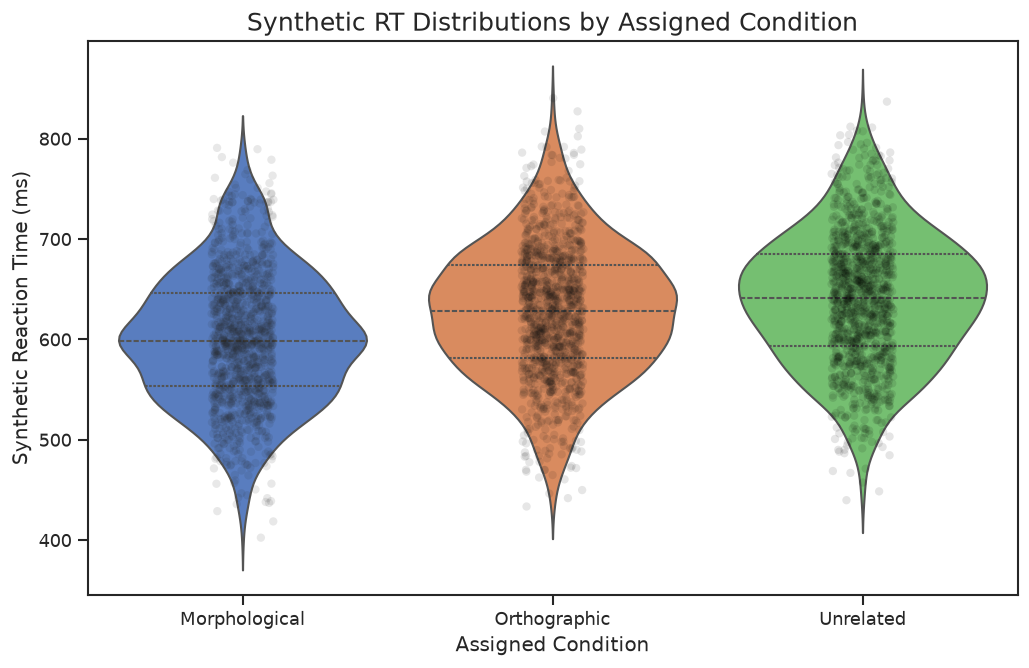

In [2]:
df_clean = df_exp.loc[df_exp["RT"].between(300, 1500, inclusive="neither")].copy()
df_clean["RT_Z"] = df_clean.groupby("Subject")["RT"].transform(
    lambda values: (values - values.mean()) / values.std()
)
df_clean = df_clean.loc[np.abs(df_clean["RT_Z"]) < 2.5].copy()

print(f"Retained {len(df_clean)} synthetic rows out of {len(df_exp)}.")

plt.figure(figsize=(10, 6))
sns.violinplot(
    x="Condition",
    y="RT",
    data=df_clean,
    hue="Condition",
    inner="quartile",
    palette="muted",
    legend=False,
)
sns.stripplot(
    x="Condition",
    y="RT",
    data=df_clean,
    hue="Condition",
    palette="dark:black",
    alpha=0.1,
    jitter=True,
    legend=False,
)
plt.title("Synthetic RT Distributions by Assigned Condition", fontsize=15)
plt.ylabel("Synthetic Reaction Time (ms)", fontsize=12)
plt.xlabel("Assigned Condition", fontsize=12)
plt.show()

## 5. Participant Random-Intercept LMM

The model below estimates the fixed effect of `Condition` with `Unrelated` as the reference and a random intercept for synthetic participant ID. It is not a crossed subject-item model. Because generated item clustering is omitted, inferential quantities do not account for that source of dependence.

In [3]:
df_clean["Condition"] = pd.Categorical(
    df_clean["Condition"],
    categories=["Unrelated", "Orthographic", "Morphological"],
)

model = smf.mixedlm(
    "RT ~ C(Condition)",
    df_clean,
    groups=df_clean["Subject"],
)
lmm_result = model.fit()

print(lmm_result.summary())
print("\n[Descriptive comparison with prespecified inputs]")
comparisons = {
    "Orthographic": ("C(Condition)[T.Orthographic]", -10.0),
    "Morphological": ("C(Condition)[T.Morphological]", -40.0),
}

for label, (term, prespecified) in comparisons.items():
    estimate = lmm_result.params[term]
    print(
        f"{label} vs Unrelated: estimated = {estimate:.2f} ms; "
        f"prespecified = {prespecified:.2f} ms; "
        f"difference = {estimate - prespecified:.2f} ms"
    )

print(
    "\nThis is a descriptive comparison for one simulated dataset only. "
    "The fitted model does not account for item clustering, and the results "
    "are not empirical evidence of priming in human readers."
)

                    Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       RT         
No. Observations:         3562          Method:                   REML       
No. Groups:               40            Scale:                    2213.0937  
Min. group size:          88            Log-Likelihood:           -18854.4533
Max. group size:          90            Converged:                Yes        
Mean group size:          89.0                                               
-----------------------------------------------------------------------------
                               Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------
Intercept                      640.668    7.584  84.480 0.000 625.805 655.532
C(Condition)[T.Orthographic]   -13.500    1.932  -6.988 0.000 -17.287  -9.714
C(Condition)[T.Morphological]  -39.675    1.934 -20.514 0.000 -43.465 -35.884
Group 